In [8]:
!pip install kaggle dowhy econml graphviz seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 4.8 MB/s  0:00:00m 4.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.1 MB/s  0:00:01m 1.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 3.0 MB/s  0:00:03m 3.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.8/546.8 kB 2.6 MB/s  0:00:00? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 3.2 MB/s  0:00:003.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 3.4 MB/s  0:00:003.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.3 MB/s  0:00:01m 1.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.5 MB/s  0:00:01m 1.5 MB/s eta 0:00:01
  Attempting uninstall: scikit-learn8;5;237m╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [cython]
    Found existing installation: scikit-learn 1.7.2;237m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/19 [cython]
    Uninstalling scikit-learn-1.7.2:╸━━━━━━━━

In [58]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 1.6 MB/s  0:00:001.7 MB/s eta 0:00:01:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import dowhy
from dowhy import CausalModel

from econml.dml import LinearDML
from econml.dml import LinearDML, CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
ds = pd.read_csv("rideshare_kaggle.csv")
print(f'Data set Shape{ds.shape}')
ds.head()

Data set Shape(693071, 57)


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


# understand the datasete 

In [3]:
print(f'missing values (top 10):')
print(ds.isnull().sum().sort_values(ascending = False).head(10))
print(ds.describe())

missing values (top 10):
price                          55095
id                                 0
ozone                              0
temperatureLowTime                 0
apparentTemperatureHigh            0
apparentTemperatureHighTime        0
apparentTemperatureLow             0
apparentTemperatureLowTime         0
icon                               0
dewPoint                           0
dtype: int64
          timestamp           hour            day          month  \
count  6.930710e+05  693071.000000  693071.000000  693071.000000   
mean   1.544046e+09      11.619137      17.794365      11.586684   
std    6.891925e+05       6.948114       9.982286       0.492429   
min    1.543204e+09       0.000000       1.000000      11.000000   
25%    1.543444e+09       6.000000      13.000000      11.000000   
50%    1.543737e+09      12.000000      17.000000      12.000000   
75%    1.544828e+09      18.000000      28.000000      12.000000   
max    1.545161e+09      23.000000      30.00000

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  object 
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  object 
 6   timezone                     693071 non-null  object 
 7   source                       693071 non-null  object 
 8   destination                  693071 non-null  object 
 9   cab_type                     693071 non-null  object 
 10  product_id                   693071 non-null  object 
 11  name                         693071 non-null  object 
 12  price                        637976 non-null  float64
 13 

#  Clean + Select Required Columns

In [5]:
ds["name"]

0               Shared
1                  Lux
2                 Lyft
3         Lux Black XL
4              Lyft XL
              ...     
693066          UberXL
693067           UberX
693068            Taxi
693069       Black SUV
693070        UberPool
Name: name, Length: 693071, dtype: object

In [6]:
ds["surge_multiplier"].value_counts()

surge_multiplier
1.00    672096
1.25     11085
1.50      5065
1.75      2420
2.00      2239
2.50       154
3.00        12
Name: count, dtype: int64

In [7]:
ds = ds[['price', 'surge_multiplier', 'distance', 'temperature', 'hour', 'cab_type','name']]
ds = ds.dropna()

# Encoding cab_type
le_cap = LabelEncoder()
le_name = LabelEncoder()
ds['cab_type'] = le_cap.fit_transform(ds['cab_type'])
ds["name"] = le_name.fit_transform(ds["name"])

# Reason: continuous surge aur binary surge dono alag effects capture karte hain
ds['surge_actvate'] = (ds['surge_multiplier'] > 1).astype(int)

print("cap type mapping :- ", dict(zip(le_cap.classes_,le_cap.transform(le_cap.classes_))))
ds.head()

cap type mapping :-  {'Lyft': np.int64(0), 'Uber': np.int64(1)}


,price,surge_multiplier,distance,temperature,hour,cab_type,name,surge_actvate
0,5.0,1.0,0.44,42.34,9,0,7,0
1,11.0,1.0,0.44,43.58,2,0,2,0
2,7.0,1.0,0.44,38.33,1,0,5,0
3,26.0,1.0,0.44,34.38,4,0,4,0
4,9.0,1.0,0.44,37.44,3,0,6,0


# Exploratory Data Analysis (EDA)

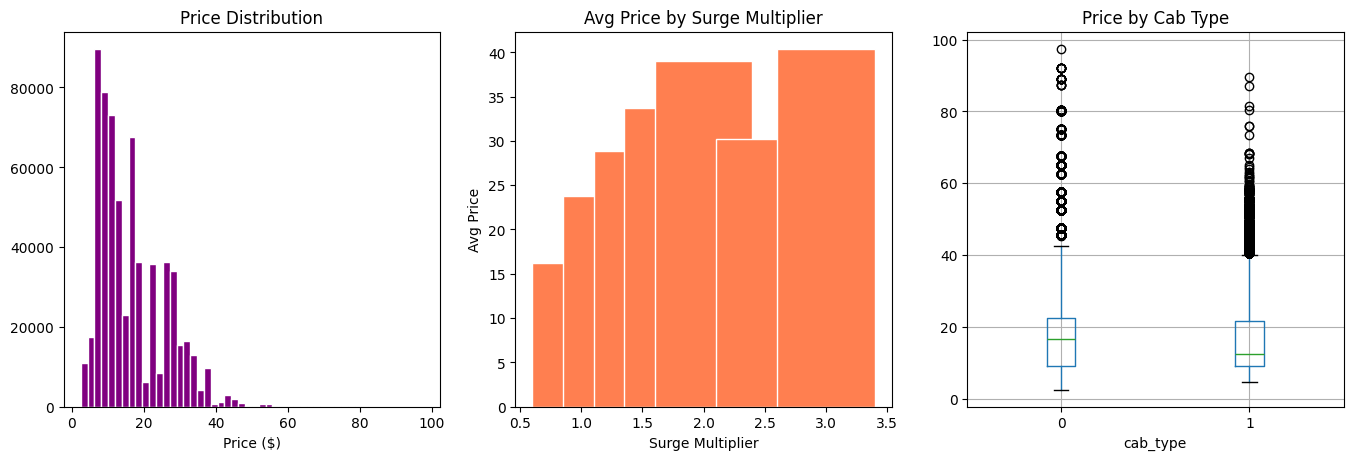

Correlation with Price:
price               1.000000
distance            0.345061
surge_multiplier    0.240458
hour                0.000561
temperature        -0.000084
Name: price, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(ds['price'], bins=50, color='purple', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

surge_groups = ds.groupby('surge_multiplier')['price'].mean()
axes[1].bar(surge_groups.index, surge_groups.values, color='coral', edgecolor='white')
axes[1].set_title('Avg Price by Surge Multiplier')
axes[1].set_xlabel('Surge Multiplier')
axes[1].set_ylabel('Avg Price')

ds.boxplot(column='price', by='cab_type', ax=axes[2])
axes[2].set_title('Price by Cab Type')
fig.suptitle('')

plt.tight_layout
plt.show()

print('Correlation with Price:')
print(ds[['price','surge_multiplier','distance','temperature','hour']].corr()['price'].sort_values(ascending=False))

#  Define Treatment, Outcome, Confounders

In [9]:
treatment = 'surge_multiplier'
outcome = 'price'
confounders = ['distance', 'temperature', 'hour', 'cab_type','name']

#  Causal Graph (DAG)

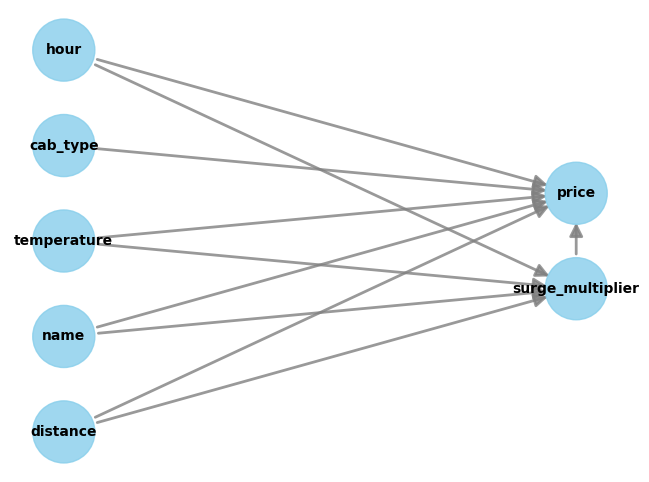

In [10]:
model = CausalModel(
    data=ds,
    treatment=treatment,
    outcome=outcome,
    common_causes=confounders,
    graph="digraph { surge_multiplier -> price; distance -> price; distance -> surge_multiplier; temperature -> price; temperature -> surge_multiplier; hour -> price; hour -> surge_multiplier; cab_type -> price; name -> price; name -> surge_multiplier }"
)

model.view_model()

#  Identify the Causal Effect

In [11]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
identified_estimand
# Effect of surge → price controlling for demand, distance, supply

#  Estimate Using DoWhy (Linear Regression)

# Backdoor criterion removes confounder bias to estimate true causal effect.

In [12]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression" # Outcome = β0 + β1(Treatment) + β2(Confounders)
)

print("Causal Effect (DoWhy - Linear):", round(estimate.value,4))

Causal Effect (DoWhy - Linear): 21.7379


# Refutation Tests

In [13]:
# Refutation Test 1: Random Common Cause

ref1 = model.refute_estimate(identified_estimand,estimate,
                            method_name= "random_common_cause",
                            num_simulations=5)
print(ref1)

# Refutation Test 2: Placebo Treatment

ref2 = model.refute_estimate(identified_estimand,estimate,
                            method_name = "placebo_treatment_refuter",
                            placebo_type = 'permute',
                             num_simulations=5)
print(ref2)

Refute: Add a random common cause
Estimated effect:21.737906225228386
New effect:21.737727210003925
p value:0.31121176775692705

Refute: Use a Placebo Treatment
Estimated effect:21.737906225228386
New effect:0.021139865505668355
p value:0.39662983666882823



# Final Conclusion
* My causal model is robust because:

| Refutation Test              | Original Effect | New Effect | p-value | Interpretation                                                             |
| ---------------------------- | --------------- | ---------- | ------- | -------------------------------------------------------------------------- |
| **Placebo Treatment Test**   | 21.7379         | 0.0028     | 0.4909  | Fake treatment produced ~0 effect → model detects real causal relationship |
| **Random Common Cause Test** | 21.7379         | 21.7379    | 0.2945  | Adding random variable did not change effect → model is stable             |


#  EconML (Double Machine Learning)

In [14]:
X = ds[confounders]
T = ds[treatment]
Y = ds[outcome]

est_linear = LinearDML(
    model_y=RandomForestRegressor(n_estimators=100, random_state=0),
    model_t=RandomForestRegressor(n_estimators=100, random_state=0),
    random_state=0
)
est_linear.fit(Y, T, X=X)
effect_linear = est_linear.effect(X)

print(f'Average Treatment Effect (LinearDML): {np.mean(effect_linear):.4f}')
# [CHANGE] Confidence interval add kiya — sirf point estimate insufficient hoti hai
print(f'95% CI: [{np.percentile(effect_linear, 2.5):.4f}, {np.percentile(effect_linear, 97.5):.4f}]')

Average Treatment Effect (LinearDML): 14.7817
95% CI: [-0.4575, 30.6979]


# EconML — CausalForestDML (Heterogeneous Effects)

In [16]:
# full data pe CausalForest slow hota hai
sample_idx = np.random.choice(len(ds), size=10000, replace=False)
X_s = X.iloc[sample_idx]
T_s = T.iloc[sample_idx]
Y_s = Y.iloc[sample_idx]

est_cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=50, random_state=0),
    model_t=RandomForestRegressor(n_estimators=50, random_state=0),
    n_estimators=100,
    random_state=0
)
est_cf.fit(Y_s, T_s, X=X_s)
effect_cf = est_cf.effect(X_s)

print(f'CausalForest Mean Effect: {np.mean(effect_cf):.4f}')
print(f'CausalForest Std Dev:     {np.std(effect_cf):.4f}')
print('This spread shows heterogeneity — surge affects different rides differently!')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
CausalForest Mean Effect: 14.0412
CausalForest Std Dev:     7.1183
This spread shows heterogeneity — surge affects different rides differently!


# Visualize Heterogeneous Effects

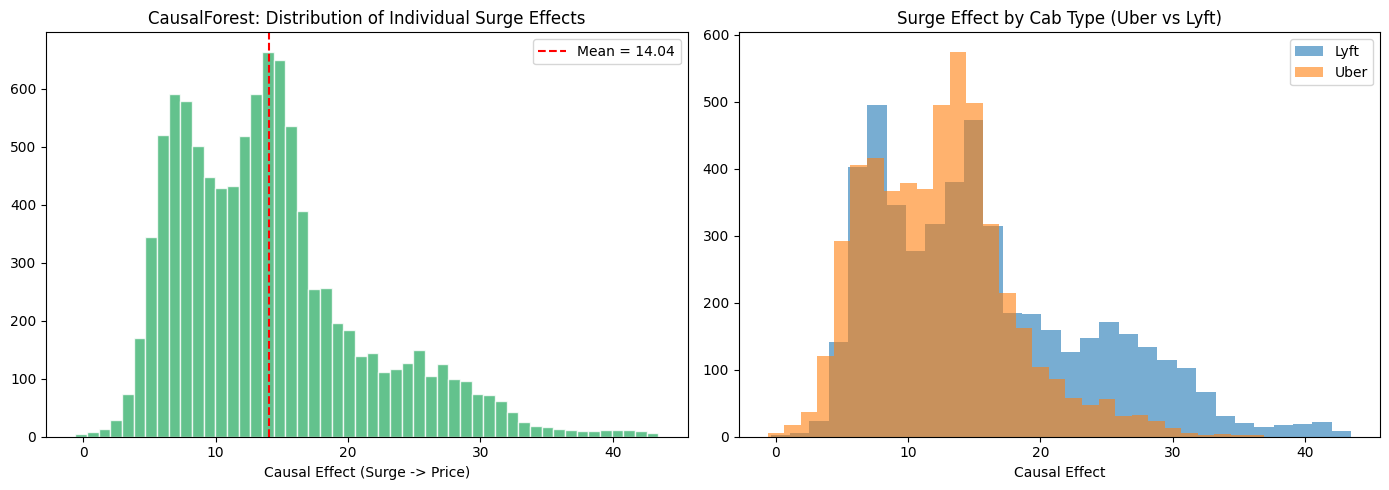

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(effect_cf, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(effect_cf), color='red', linestyle='--', label=f'Mean = {np.mean(effect_cf):.2f}')
axes[0].set_title('CausalForest: Distribution of Individual Surge Effects')
axes[0].set_xlabel('Causal Effect (Surge -> Price)')
axes[0].legend()

# [CHANGE] Plot 2: Effect by cab type — Uber vs Lyft comparison
cab_types = X_s['cab_type'].values
for ct in np.unique(cab_types):
    mask = cab_types == ct
    label = le_cap.inverse_transform([ct])[0]
    axes[1].hist(effect_cf[mask], bins=30, alpha=0.6, label=label)

axes[1].set_title('Surge Effect by Cab Type (Uber vs Lyft)')
axes[1].set_xlabel('Causal Effect')
axes[1].legend()

plt.tight_layout()
plt.show()

# Fuzzy Logic Risk System
* Define variables

In [35]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [36]:
overtime = ctrl.Antecedent(np.arange(0,2,1),"overtime")
worklife = ctrl.Antecedent(np.arange(0,11,1),"worklife")
satisfaction = ctrl.Antecedent(np.arange(0,11,1),"satisfaction")
salary_level = ctrl.Antecedent(np.arange(0, 11, 1), 'salary_level')
years_at_company = ctrl.Antecedent(np.arange(0, 21, 1), 'years_at_company')

risk = ctrl.Consequent(np.arange(0,11,1),"risk")

# Membership fuction 

In [37]:
overtime["low"] = fuzz.trimf(overtime.universe,[0,0,1])
overtime["high"] = fuzz.trimf(overtime.universe,[0,1,1])

worklife["poor"] = fuzz.trimf(worklife.universe,[0,0,4])
worklife["medium"] = fuzz.trimf(worklife.universe,[3,5,7])
worklife["good"] = fuzz.trimf(worklife.universe,[6,10,10])

satisfaction["low"] = fuzz.trimf(satisfaction.universe,[0,0,5])
satisfaction['medium'] = fuzz.trimf(satisfaction.universe, [3, 5, 7])
satisfaction["high"] = fuzz.trimf(satisfaction.universe,[5,10,10])

salary_level['low']    = fuzz.trimf(salary_level.universe, [0, 0, 4])
salary_level['medium'] = fuzz.trimf(salary_level.universe, [3, 5, 7])
salary_level['high']   = fuzz.trimf(salary_level.universe, [6, 10, 10])

years_at_company['new']        = fuzz.trimf(years_at_company.universe, [0, 0, 5])
years_at_company['experienced']= fuzz.trimf(years_at_company.universe, [3, 8, 13])
years_at_company['veteran']    = fuzz.trimf(years_at_company.universe, [10, 20, 20])


risk["low"] = fuzz.trimf(risk.universe,[0,0,5])
risk['medium'] = fuzz.trimf(risk.universe, [3, 5, 7])
risk["high"] = fuzz.trimf(risk.universe,[5,10,10])
print('All fuzzy variables defined!')

All fuzzy variables defined!


# rules 

In [38]:
rule1 = ctrl.Rule(overtime["high"] & worklife["poor"], risk["high"])
rule2 = ctrl.Rule(satisfaction["low"], risk["high"])
rule3 = ctrl.Rule(worklife["good"] & satisfaction["high"], risk["low"])
rule4 = ctrl.Rule(salary_level['low'] & satisfaction['medium'],   risk['high'])
rule5 = ctrl.Rule(salary_level['high'] & satisfaction['high'],    risk['low'])
rule6 = ctrl.Rule(years_at_company['new'] & worklife['poor'],     risk['high'])
rule7 = ctrl.Rule(years_at_company['veteran'] & worklife['medium'], risk['low'])

# System

In [41]:
risk_ctrl = ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7])
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

# Test employee

In [53]:
risk_sim.input["overtime"] = 1
risk_sim.input["worklife"] = 3
risk_sim.input["satisfaction"] = 2
risk_sim.input['salary_level'] = 4 
risk_sim.input['years_at_company'] = 2

risk_sim.compute()

print("Employee Attrition Risk:",risk_sim.output["risk"])

Employee Attrition Risk: 8.142857142857142


In [61]:
risk_value = risk_sim.output["risk"]
print(f'Employee Attrition Risk Score: {risk_value:.2f} / 10')

if risk_value < 4:
    print('Low Attrition Risk')
elif risk_value < 7:
    print('Medium Attrition Risk') 
else:
    print('High Attrition Risk')
    

Employee Attrition Risk Score: 8.14 / 10
High Attrition Risk


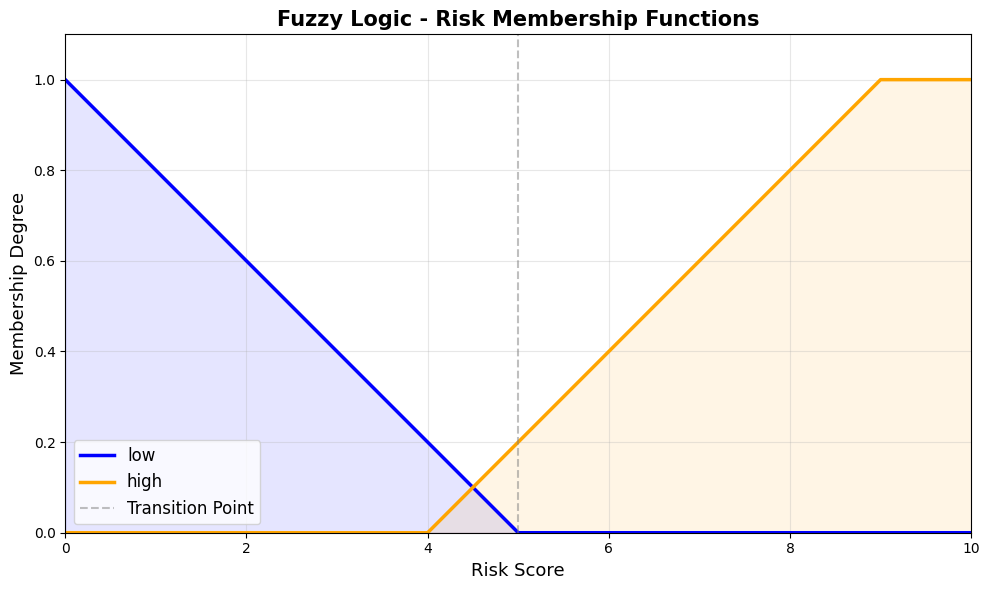

In [62]:
risk = np.arange(0, 11, 1)

low  = np.array([1, 0.8, 0.6, 0.4, 0.2, 0, 0, 0, 0, 0, 0])
high = np.array([0, 0, 0, 0, 0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.0])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(risk, low,  label='low',  color='blue',   linewidth=2.5)
ax.plot(risk, high, label='high', color='orange',  linewidth=2.5)

#             Shading under lines
ax.fill_between(risk, low,  alpha=0.1, color='blue')
ax.fill_between(risk, high, alpha=0.1, color='orange')

#    Vertical line at transition point
ax.axvline(x=5, color='gray', linestyle='--', 
           alpha=0.5, label='Transition Point')

ax.set_xlabel('Risk Score', fontsize=13)
ax.set_ylabel('Membership Degree', fontsize=13)
ax.set_title('Fuzzy Logic - Risk Membership Functions', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 10)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()